In [13]:
!pip install nltk bert-score pandas torch transformers tokenizers

import torch
import torch.nn as nn
import pandas as pd
import time
import math
import nltk
from bert_score import score
from transformers import PreTrainedTokenizerFast

nltk.download('punkt')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"NMT Inference Environment Initialized. Using device: {device}")

print("Loading Custom BPE Tokenizer...")
try:
    tokenizer = PreTrainedTokenizerFast.from_pretrained("./custom_sanskrit_tokenizer")
    vocab_size = len(tokenizer)
    PAD_IDX = tokenizer.pad_token_id
    BOS_IDX = tokenizer.bos_token_id
    EOS_IDX = tokenizer.eos_token_id
    print(f"Successfully loaded tokenizer. Vocabulary Size: {vocab_size:,}")
except Exception as e:
    print("ERROR: Could not load the tokenizer. Please ensure the 'custom_sanskrit_tokenizer' folder is in this directory.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


NMT Inference Environment Initialized. Using device: cuda
Loading Custom BPE Tokenizer...
Successfully loaded tokenizer. Vocabulary Size: 5,000


In [14]:
from sanskrit_model import CustomSanskritTransformer

print("Initializing the Micro-Transformer...")
model = CustomSanskritTransformer(vocab_size=vocab_size).to(device)

try:
    model.load_state_dict(torch.load('best_custom_nmt_model.pth', map_location=device))
    model.eval()
    print("Successfully loaded 'best_custom_nmt_model.pth'")
except FileNotFoundError:
    print("ERROR: 'best_custom_nmt_model.pth' not found in the current directory.")

Initializing the Micro-Transformer...
Successfully loaded 'best_custom_nmt_model.pth'


In [15]:
def load_translation_data(sa_path, en_path):
    df_sa = pd.read_csv(sa_path)
    df_en = pd.read_csv(en_path)
    aligned_df = pd.merge(df_sa, df_en, on='Source_id', how='inner').sort_values('Source_id').reset_index(drop=True)
    return aligned_df

print("Loading Test Data...")
test_df = load_translation_data('test_sa.csv', 'test_en.csv')
print(f"Loaded {len(test_df)} testing pairs.")

def translate_sentence(model, sentence, tokenizer, max_len=64):
    model.eval()
    src_text = f"[BOS] {sentence} [EOS]"
    src_encoded = tokenizer(src_text, return_tensors="pt", max_length=max_len, truncation=True)
    src = src_encoded['input_ids'].to(device)
    src_padding_mask = (src == PAD_IDX).to(device)

    tgt_ids = [BOS_IDX]

    for i in range(max_len):
        tgt_tensor = torch.LongTensor(tgt_ids).unsqueeze(0).to(device)
        tgt_mask = model.generate_square_subsequent_mask(tgt_tensor.size(1)).to(device)

        with torch.no_grad():
            output = model(src, tgt_tensor, tgt_mask=tgt_mask, src_padding_mask=src_padding_mask)

        next_token = output[0, -1, :].argmax().item()

        if next_token == EOS_IDX:
            break

        tgt_ids.append(next_token)

    return tokenizer.decode(tgt_ids[1:], skip_special_tokens=True)

Loading Test Data...
Loaded 1000 testing pairs.


In [16]:
print("Starting Autoregressive Inference on the Test Set...")
start_time = time.time()

predicted_translations = []
gold_translations = test_df['Sentence_en'].tolist()

for idx, row in test_df.iterrows():
    pred_en = translate_sentence(model, row['Sentence_sa'], tokenizer)
    predicted_translations.append(pred_en)

    if idx > 0 and idx % 500 == 0:
        print(f"Translated {idx} sentences...")

end_time = time.time()
inference_time = end_time - start_time

print("\n" + "="*45)
print("         OFFICIAL EVALUATION METRICS")
print("="*45)
print(f"Total Parameters: {total_params:,}")
print(f"Inference Time:   {inference_time:.2f} seconds")
print("-" * 45)

# NLTK BLEU Calculation
import warnings
warnings.filterwarnings("ignore")
nltk.download('punkt_tab', quiet=True)

bleu_scores = [nltk.translate.bleu_score.sentence_bleu([nltk.word_tokenize(g)], nltk.word_tokenize(p))
               for g, p in zip(gold_translations, predicted_translations)]
average_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"Average NLTK BLEU Score: {average_bleu:.4f}")

# BERTScore Calculation
print("Calculating BERTScore...")
P, R, F1 = score(predicted_translations, gold_translations, lang="en", verbose=False, rescale_with_baseline=True)
average_f1 = F1.mean().item()
print(f"BERTScore (F1 Rescaled): {average_f1:.4f}")
print("="*45 + "\n")

Starting Autoregressive Inference on the Test Set...
Translated 500 sentences...

         OFFICIAL EVALUATION METRICS
Total Parameters: 5,239,688
Inference Time:   307.95 seconds
---------------------------------------------
Average NLTK BLEU Score: 0.0033
Calculating BERTScore...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore (F1 Rescaled): -0.1118



In [17]:
print("Generating submission.csv file...")

submission_df = pd.DataFrame({
    'Source_id': test_df['Source_id'],
    'Sentence_en': predicted_translations
})

submission_df.to_csv('submission.csv', index=False, encoding='utf-8')

Generating submission.csv file...


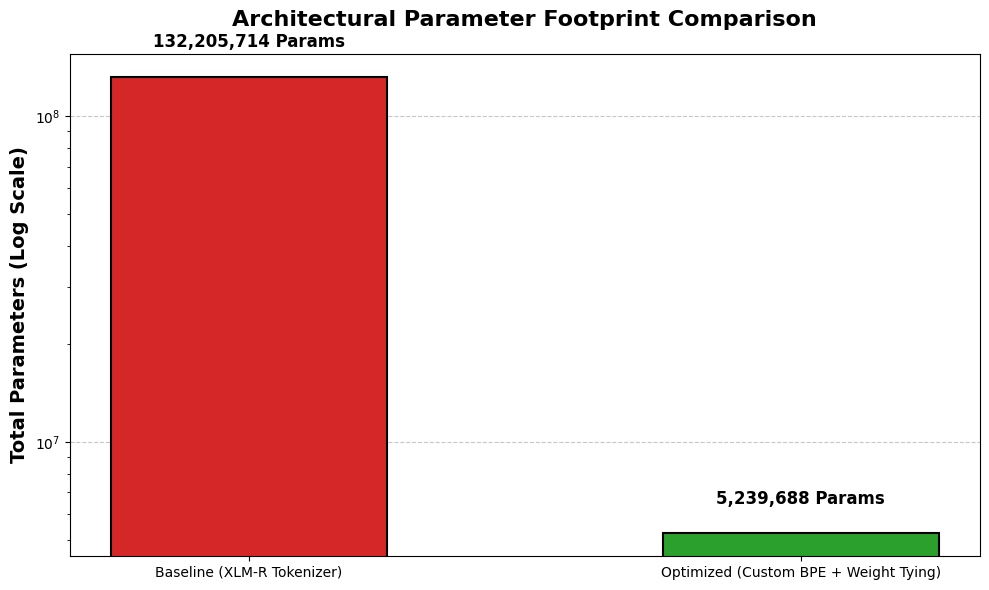

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_parameter_efficiency():
    models = ['Baseline (XLM-R Tokenizer)', 'Optimized (Custom BPE + Weight Tying)']
    parameters = [132205714, 5239688]

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(models, parameters, color=['#d62728', '#2ca02c'], width=0.5, edgecolor='black', linewidth=1.5)

    ax.set_yscale('log')
    ax.set_ylabel('Total Parameters (Log Scale)', fontsize=14, fontweight='bold')
    ax.set_title('Architectural Parameter Footprint Comparison', fontsize=16, pad=20, fontweight='bold')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                f'{int(height):,} Params',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('parameter_efficiency_comparison.png', dpi=300)
    plt.show()

plot_parameter_efficiency()

In [18]:
print("="*50)
print(" ASSIGNMENT 2 METRICS ")
print("="*50)
print(f"1. Total Model Parameters: {total_params:,}")
print(f"2. Total Inference Time:   {inference_time:.2f} seconds")
print(f"3. NLTK BLEU Score:        {average_bleu:.4f}")
print(f"4. BERTScore (F1):         {average_f1:.4f}")
print("="*50)

 ASSIGNMENT 2 METRICS 
1. Total Model Parameters: 5,239,688
2. Total Inference Time:   307.95 seconds
3. NLTK BLEU Score:        0.0033
4. BERTScore (F1):         -0.1118
